In [121]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

# KNN Model: Predicting Potential Disruptions in Shipments
Why a KNN model? Well, because logistic regression and decision trees were already taken! Also, for the sake of testing another classification model, just to see if it works (it didn't).

# 1. Data Loading

In [122]:
df = pd.read_csv("supply_chain.csv")


# 2. EDA

In [123]:
# Just want to summarize the dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [124]:
df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [125]:
# Viewing the shape
df.shape

(5000, 14)

In [126]:
# Any columns that I need to delete?
# Yea, Date and Shipment_ID don't need those.
cols_del = ["Shipment_ID", "Date"]
df2 = df.drop(columns=cols_del)

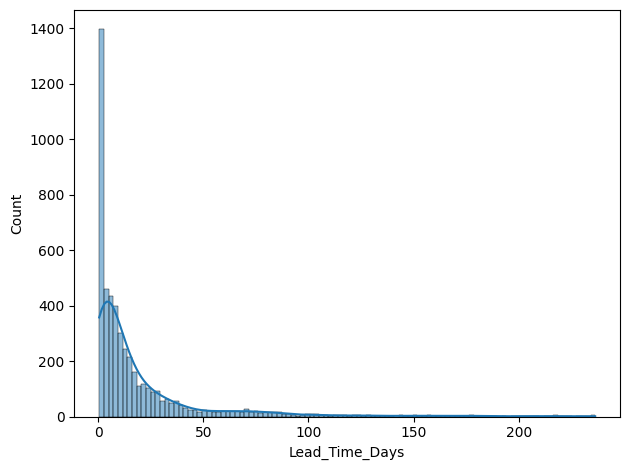

In [127]:
# Looking at data wrangler every distribution looks good except for this:
sns.histplot(data=df2, x="Lead_Time_Days", kde=True)
plt.tight_layout()
plt.show()

# How can we fix this?

In [128]:
print(df2["Lead_Time_Days"].skew())  # Just found out this was a thing!
# Anyway, this is a right skew so I'm going to log transform
# before scaling.
df2["Lead_Time_Days"] = np.log1p(df2["Lead_Time_Days"])


3.349222712647645


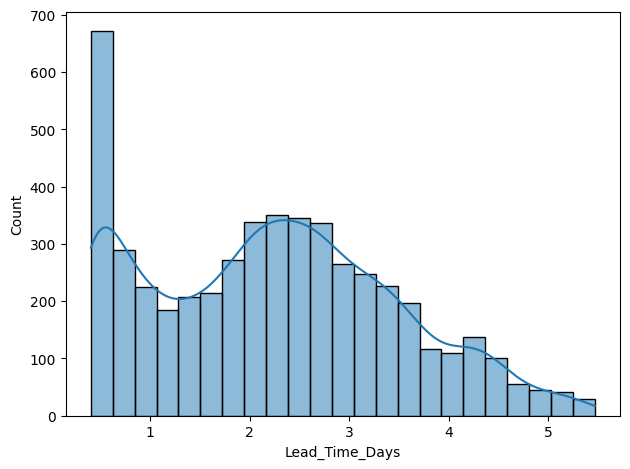

In [129]:
# Now let's look at it.
sns.histplot(data=df2, x="Lead_Time_Days", kde=True)
plt.tight_layout()
plt.show()

# Much better!!

In [130]:
# Everything else looks good.
# I could do some reduction in Origin_Port and Destination_Port,
# but it's only eight and nine distinct values, so I think it will be okay.

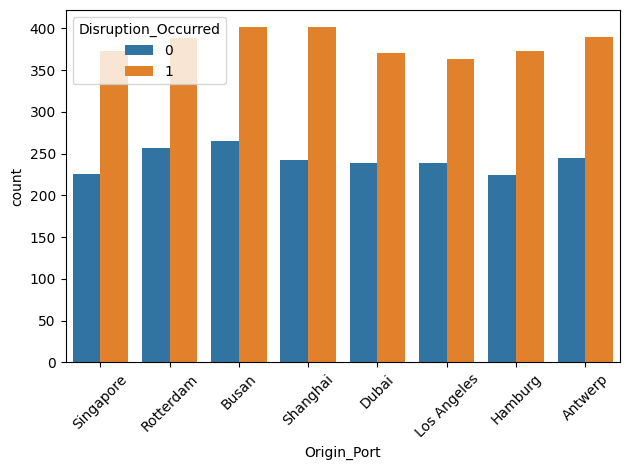

In [131]:
# I lied, let's look at these categorical variables
# Countplot of Origin_Port
sns.countplot(data=df2, x="Origin_Port", hue="Disruption_Occurred")
plt.xticks(rotation=45) # Just to see the x labels better
plt.tight_layout()
plt.show()

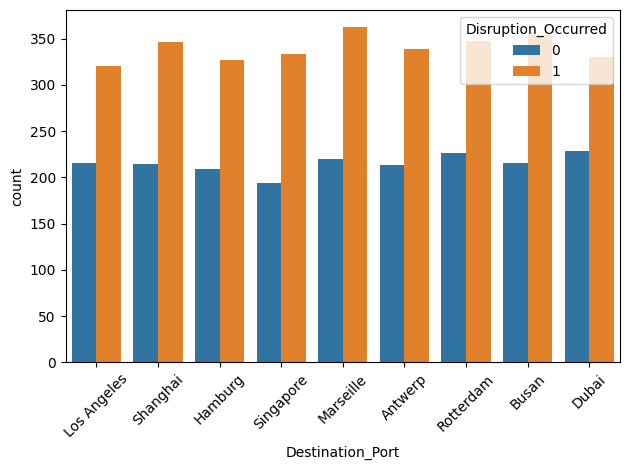

In [132]:
# Countplot of Destination_Port
sns.countplot(data=df2, x="Destination_Port", hue="Disruption_Occurred")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Neither of these variables are collapsable in my humble opinion--they are not necessarily close to each other region-wise and hold significant information independently. Additionally, they hold a pretty even distribution across the board, as revealed by Data Wrangler.

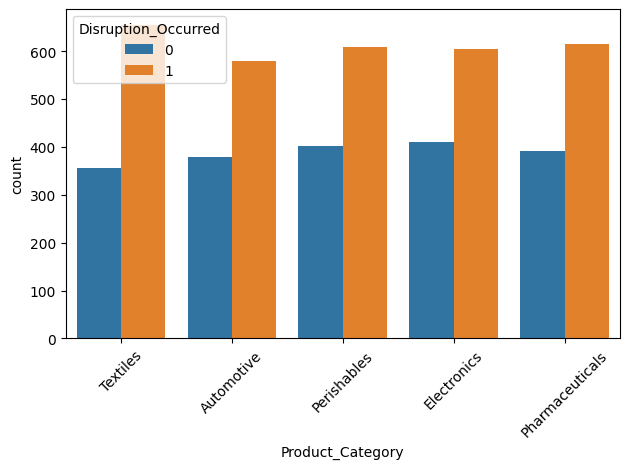

In [133]:
# Maybe product category will reveal something
# Countplot of Product_Category
sns.countplot(data=df2, x="Product_Category", hue="Disruption_Occurred")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Nope, nothing

So, I can't exaclty make a corr matrix yet because a good chunk of this data is categorical and the numerical data is not standardized.

# 3. Data Splitting

In [134]:
# Splitting the data.
X = df2.drop(columns="Disruption_Occurred")
y = df2["Disruption_Occurred"]

In [135]:
prev = sum(y) / len(y)
print(prev)

# 60/40 imbalance not too bad

0.6126


In [136]:
# Split the data.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,    
    stratify=y,
    test_size=0.2,    
    random_state=42
)

# Just to verify with the prevalance 
print(f"Train: {X_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")
print(f"Train positive rate: {y_train.mean():.3%}") # Close if not equal to prev
print(f"Test positive rate:  {y_test.mean():.3%}")

Train: 4000 rows
Test: 1000 rows
Train positive rate: 61.250%
Test positive rate:  61.300%


# 4. Creating the Baseline Model


The first model utitlizes KNeighborsClassifier from sklearn. A pipeline was used to ensure that data is standardized and hot-encoded after data splitting, preventing any potential data leakage. 

In [ ]:
CATS = [
    "Origin_Port", 
    "Destination_Port", 
    "Transport_Mode",
    "Product_Category", 
    "Weather_Condition"
]

NUMERIC = [
    "Distance_km", 
    "Weight_MT", 
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score", 
    "Carrier_Reliability_Score", 
    "Lead_Time_Days"
]

# Preprocessing steps for each column type for Pipeline
preprocessor = ColumnTransformer(transformers=[
    ("num", MinMaxScaler(), NUMERIC),
    ("cat", Pipeline(steps=[
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ("scale", MinMaxScaler())
    ]), CATS)
    # sparse_output needs to be false for svd_solver="full" down the load.
    # sprase_output only stores non-zero values, but for mathematical
    # processes like svd, we need those zeroes/full matrix.
    # Additionally, the OHE categorical variables needed to be scaled as well!
    # They are not split into binary columns, and then scaled
])

# Creating the pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Fitting and evaluating the model
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

AUC = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
print(f"AUC: {AUC:.4f}")

              precision    recall  f1-score   support

           0       0.59      0.52      0.55       387
           1       0.72      0.77      0.74       613

    accuracy                           0.67      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg       0.67      0.67      0.67      1000

AUC: 0.7352


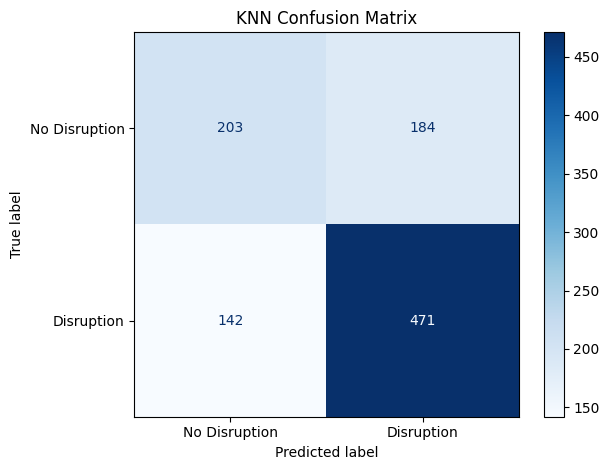

In [138]:
# Let me look at the confusion matrix.
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disruption", "Disruption"])
disp.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

# 5. Improving The Baseline Model

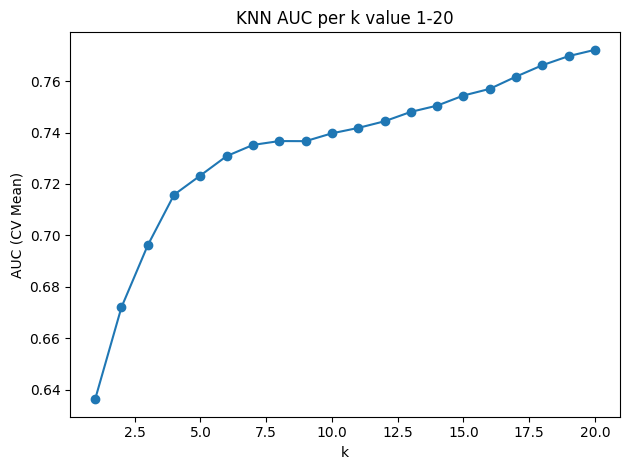

In [139]:
# Let me try adjusting k and 5-fold CV and see if that helps.
# Plot will be used to visualize the best k
means = []
for k in range(1, 21):
    knn_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipeline, X_train, y_train, cv=5, scoring="roc_auc")
    means.append(scores.mean())

plt.plot(range(1, 21), means, marker="o")
plt.xlabel("k")
plt.ylabel("AUC (CV Mean)")
plt.title("KNN AUC per k value 1-20")
plt.tight_layout()
plt.show()

The AUC score improved as the number of neighbors increased, but I have intuition that this might just be an example of overfitting. There's a significant loss of improvement after 5, so I think 5 will be suffice.

Now let's try using the weights parameter. When setting the weights parameter to distance, the model prioritizes closer neighbors so that they carry more influence than ones that are further away. I doubt this will have too much influence given the 60/40 class imbalance.

In [140]:
# Settings weights = 'distance' & new pipeline
pipeline2 = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5, weights="distance"))
])

pipeline2.fit(X_train, y_train)
print(classification_report(y_test, pipeline2.predict(X_test)))

AUC2 = roc_auc_score(y_test, pipeline2.predict_proba(X_test)[:, 1])
print(f"AUC: {AUC2:.4f}")

# Okay this did not change anything much at all

              precision    recall  f1-score   support

           0       0.59      0.52      0.55       387
           1       0.72      0.77      0.74       613

    accuracy                           0.68      1000
   macro avg       0.65      0.65      0.65      1000
weighted avg       0.67      0.68      0.67      1000

AUC: 0.7365


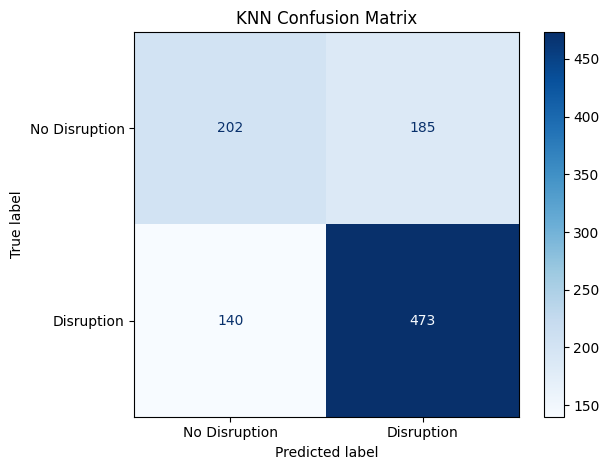

In [141]:
# Let's take a look at the confusion matrix for this model
cm2 = confusion_matrix(y_test, pipeline2.predict(X_test))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["No Disruption", "Disruption"])
disp2.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

# only two more true positives, not much change at all

As predicted, not much change from the weight parameter. Let's move on to tweaking the features of the model to see if that has any influence.

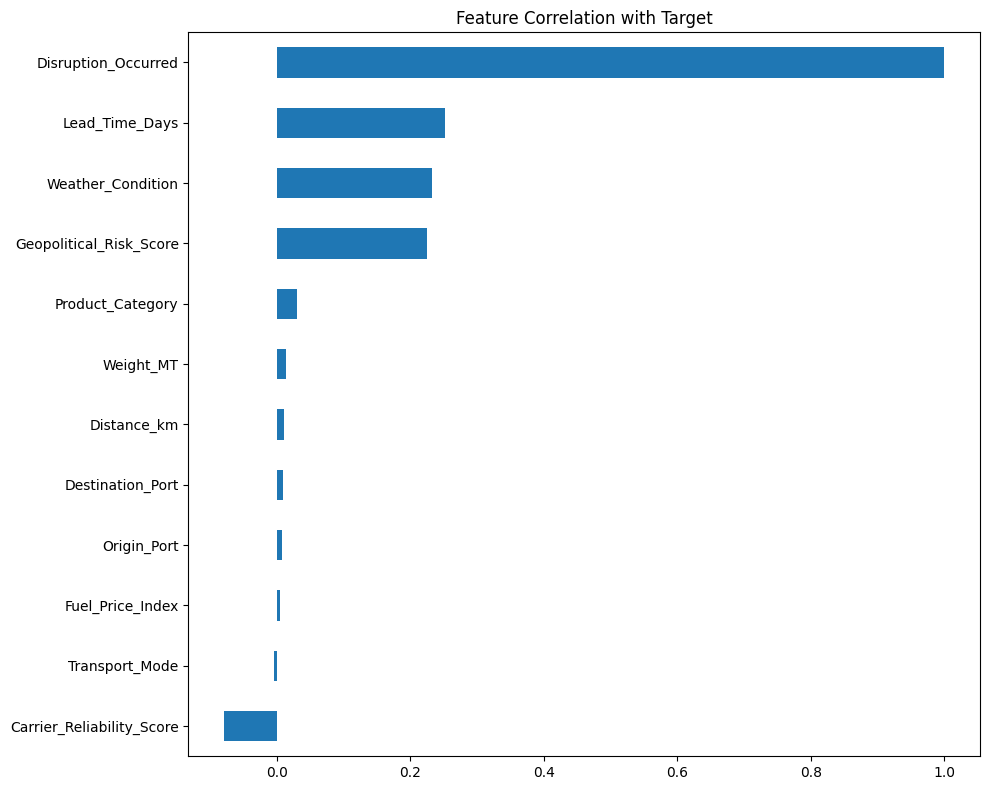

In [142]:
from sklearn.preprocessing import OrdinalEncoder

df_corr = X
df_corr[CATS] = OrdinalEncoder().fit_transform(X[CATS])
# Using ordinal encoder to keep each feature as a single column.
# Though this is not statistically correct, I believe it still provides
# a rough overview of the significant features.
# These magnitudes should be evaluated cautiously, however,
# if one feature sticks out, it may be significant.
df_corr["Disruption_Occurred"] = y

corr = df_corr.corr()["Disruption_Occurred"].sort_values()
corr.plot(kind="barh", figsize=(10, 8))
plt.title("Feature Correlation with Target")
plt.tight_layout()
plt.show()

It looks like a few of these features don't have a significant correlation with disruption occurance, so, to optimize the features, I'll use PCA as a last resort in the next model. 

# 6. Creating an Improved Model w/ PCA

In [143]:
from sklearn.decomposition import PCA

pipeline_pca = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("pca", PCA(n_components=0.95, svd_solver="full")),
    # svd_solver="full" was necessary for n_components to take a float argument.
    # This just computes the full SVD for the entire matrix
    ("model", KNeighborsClassifier(n_neighbors=5))
])

pipeline_pca.fit(X_train, y_train)
print(classification_report(y_test, pipeline_pca.predict(X_test)))

AUC_pca = roc_auc_score(y_test, pipeline_pca.predict_proba(X_test)[:, 1])
print(f"AUC: {AUC_pca:.4f}")

# Even after PCA, there is no significant improvement in performance.

              precision    recall  f1-score   support

           0       0.58      0.52      0.55       387
           1       0.72      0.77      0.74       613

    accuracy                           0.67      1000
   macro avg       0.65      0.64      0.64      1000
weighted avg       0.66      0.67      0.67      1000

AUC: 0.7212


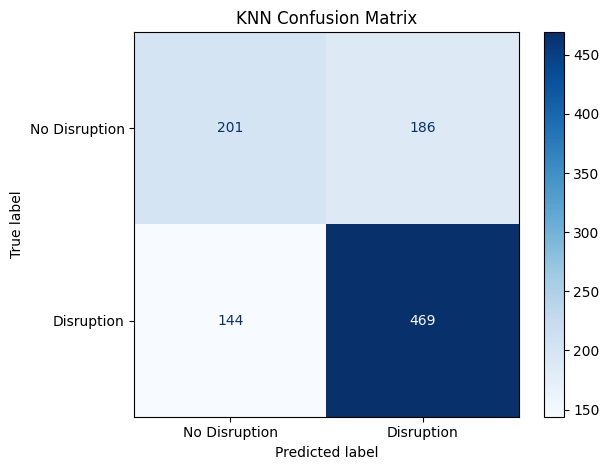

In [144]:
# Confusion matrix:
cm3 = confusion_matrix(y_test, pipeline_pca.predict(X_test))
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=["No Disruption", "Disruption"])
disp3.plot(cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()

# 7. Conclusions
Despite tuning the k value from 1-20, adjusting how the model intepreted distance for prediction (it prioritizes closer neighbors), and introducing PCA for dimensionality reduction, the model did not display any meaningful improvement from the baseline model. KNN is a distance-based algorithim that, though is used for classification, struggles with nonlinear features. For this reason, I will conclude that KNN is not the best model for this relationship. Additionally there were weak univariate relationships observed in EDA in relation to the target variable, which is not ideal for kNN due to it's distance based calculations. If the features are weak and don't separate well in a given space, all distance-based calculations will simpply add noise rather than provide a pattern. This further supports the conclusion that this dataset is most likely better captured by a more sophisticated algorithm like a decision tree or logistic regression because.

Final note: After the model was finished, it was realized that the categorical features do not mathematically work with numerical features when calculating euclidian distance. Fundamentally, this model does not work as long as either euclidian distance is used or the catagorical features are included. Becasue the categorical features are necessary and the type of distance needed requires research outside the scope of this class, I will conclude once more that this is not the appropriate algorithm. for this dataset